<a href="https://colab.research.google.com/github/atikhasan007/Machine-Learning/blob/main/Ucf_Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("odins0n/ucf-crime-dataset")

print("Path to dataset files:", path)

Contents of test_dir: ['Abuse', 'Stealing', 'Robbery', 'Vandalism', 'Shooting', 'Arson', 'NormalVideos', 'Shoplifting', 'Arrest', 'Explosion', 'RoadAccidents', 'Fighting', 'Assault', 'Burglary']
Contents of train_dir: ['Abuse', 'Stealing', 'Robbery', 'Vandalism', 'Shooting', 'Arson', 'NormalVideos', 'Shoplifting', 'Arrest', 'Explosion', 'RoadAccidents', 'Fighting', 'Assault', 'Burglary']


Loading Shoplifting: 100%|██████████| 7623/7623 [00:04<00:00, 1692.60it/s]


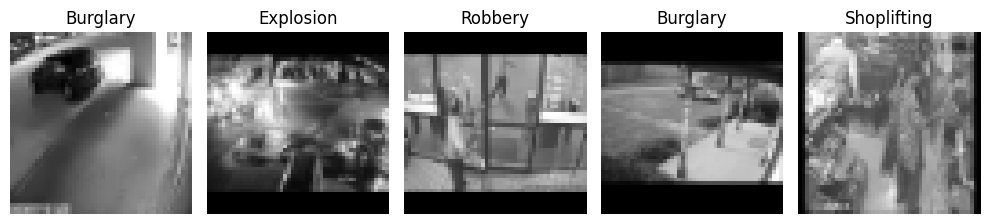

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import cv2
from tqdm import tqdm
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
    LeakyReLU, LSTM, Input, concatenate, Multiply, Softmax
)
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import time
import tensorflow as tf

# ================= PATHS ===================
test_dir = '/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Test'
train_dir = '/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train'

print("Contents of test_dir:", os.listdir(test_dir))
print("Contents of train_dir:", os.listdir(train_dir))

# ================= CATEGORIES ===================
categories_labels = {'Abuse': 0, 'Arrest': 1, 'Arson': 2, 'Assault': 3,
                     'Burglary': 4, 'Explosion': 5, 'Fighting': 6,
                     'Vandalism': 7, 'Stealing': 8, 'Robbery': 9,
                     'Shooting': 10, 'Shoplifting': 11}

# ================= LOAD DATA FUNCTION ===================
def load_data(base_dir, categories_labels):
    data = []
    for category, label in categories_labels.items():
        category_dir = os.path.join(base_dir, category)
        if os.path.isdir(category_dir):
            for filename in tqdm(os.listdir(category_dir), desc=f"Loading {category}"):
                if filename.endswith(".jpg") or filename.endswith(".png"):
                    image_path = os.path.join(category_dir, filename)
                    try:
                        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                        image = cv2.resize(image, (50, 50))
                        image = image.reshape((1,) + image.shape + (1,))
                        data.append([image, label])
                    except Exception as e:
                        print(f"Error loading image {image_path}: {e}")
    return data

# ================= LOAD TRAIN & TEST DATA ===================
training_data = load_data(train_dir, categories_labels)
test_data = load_data(test_dir, categories_labels)  # only for reference; won't be used in training

# ================= SHOW SAMPLE IMAGES ===================
total_data = training_data + test_data

def show_sample_images(data, categories_labels, num_samples=5):
    labels_to_categories = {v: k for k, v in categories_labels.items()}
    plt.figure(figsize=(10, 10))
    indices = np.random.choice(len(data), num_samples, replace=False)
    for i, idx in enumerate(indices):
        image, label = data[idx]
        image = image.reshape(50, 50)
        category_name = labels_to_categories[label]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(category_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(total_data, categories_labels, num_samples=5)

# ================= PREP DATA FOR MODEL ===================
images, labels = zip(*training_data)
images = np.array(images)
labels = np.array(labels)

if images.shape[1] == 1:
    images = np.squeeze(images, axis=1)

images_lstm = images.reshape(images.shape[0], -1, 1)  # (num_samples, 2500, 1)
seed = 42
categories = len(categories_labels)


In [ ]:

# ================= TRAIN-TEST SPLIT ===================
train_images_cnn, test_images_cnn, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.1, random_state=seed
)
train_images_lstm, test_images_lstm, _, _ = train_test_split(
    images_lstm, labels, test_size=0.1, random_state=seed
)

# One-hot encode labels
train_labels = to_categorical(train_labels, categories)
test_labels = to_categorical(test_labels, categories)

print(f"Training set size: {train_images_cnn.shape[0]}")
print(f"Test set size: {test_images_cnn.shape[0]}")

# ================= CNN BRANCH ===================
cnn_input = Input(shape=(50, 50, 1))
x = Conv2D(64, (3, 3), padding='same')(cnn_input)
x = LeakyReLU(negative_slope=0.1)(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Dropout(0.25)(x)

x = Conv2D(128, (3, 3), padding='same')(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Dropout(0.25)(x)

x = Conv2D(256, (3, 3), padding='same')(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Dropout(0.4)(x)

x = Flatten()(x)
x = Dense(256)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.5)(x)
cnn_output = x

# ================= LSTM BRANCH WITH ATTENTION ===================
lstm_input = Input(shape=(2500, 1))
l = LSTM(64, return_sequences=True)(lstm_input)
l = Dropout(0.3)(l)
l = LSTM(64, return_sequences=True)(l)
l = Dropout(0.3)(l)

attention = Dense(1, activation='tanh')(l)
attention = Softmax(axis=1)(attention)
context = Multiply()([l, attention])
context = tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), output_shape=(64,))(context)

l = Dense(128, activation='relu')(context)
l = Dropout(0.3)(l)
lstm_output = l

# ================= COMBINE BRANCHES ===================
combined = concatenate([cnn_output, lstm_output])
output = Dense(categories, activation='softmax')(combined)
model_final = Model(inputs=[cnn_input, lstm_input], outputs=output)

# ================= COMPILE & TRAIN ===================
model_final.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

plot_model(model_final, to_file='CNN_LSTM_Attention_Fixed.png', show_shapes=True)

csv_logger = CSVLogger('training_attention.log')
mc = ModelCheckpoint('CNN_LSTM_Attention.h5', monitor='val_accuracy', mode='max', save_best_only=True)

start = time.time()
history = model_final.fit(
    [train_images_cnn, train_images_lstm],
    train_labels,
    batch_size=256,
    epochs=20,
    validation_data=([test_images_cnn, test_images_lstm], test_labels),
    callbacks=[mc, csv_logger],
    verbose=1
)
print("Training time:", time.time() - start)

np.save("CNN_LSTM_Attention_history.npy", history.history)


Training set size: 265581
Test set size: 29510
Epoch 1/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5463 - loss: 3.0089

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 349s 332ms/step - accuracy: 0.5465 - loss: 3.0070 - val_accuracy: 0.9815 - val_loss: 0.0698
Epoch 2/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9609 - loss: 0.1322

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 343s 330ms/step - accuracy: 0.9609 - loss: 0.1322 - val_accuracy: 0.9893 - val_loss: 0.0426
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9743 - loss: 0.0887

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 343s 330ms/step - accuracy: 0.9743 - loss: 0.0887 - val_accuracy: 0.9930 - val_loss: 0.0247
Epoch 4/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 382s 331ms/step - accuracy: 0.9767 - loss: 0.0810 - val_accuracy: 0.9929 - val_loss: 0.0268
Epoch 5/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9783 - loss: 0.0785

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 343s 330ms/step - accuracy: 0.9783 - loss: 0.0785 - val_accuracy: 0.9941 - val_loss: 0.0232
Epoch 6/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 351s 338ms/step - accuracy: 0.9812 - loss: 0.0704 - val_accuracy: 0.9939 - val_loss: 0.0230
Epoch 7/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9792 - loss: 0.0808

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 343s 331ms/step - accuracy: 0.9792 - loss: 0.0808 - val_accuracy: 0.9943 - val_loss: 0.0265
Epoch 8/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 343s 330ms/step - accuracy: 0.9801 - loss: 0.0830 - val_accuracy: 0.9942 - val_loss: 0.0216
Epoch 9/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9823 - loss: 0.0749

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 343s 330ms/step - accuracy: 0.9823 - loss: 0.0749 - val_accuracy: 0.9945 - val_loss: 0.0257
Epoch 10/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 342s 330ms/step - accuracy: 0.9817 - loss: 0.0799 - val_accuracy: 0.9945 - val_loss: 0.0230
Epoch 11/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 342s 329ms/step - accuracy: 0.9837 - loss: 0.0745 - val_accuracy: 0.9941 - val_loss: 0.0280
Epoch 12/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 342s 330ms/step - accuracy: 0.9820 - loss: 0.0910 - val_accuracy: 0.9943 - val_loss: 0.0309
Epoch 13/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9836 - loss: 0.0843

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 342s 330ms/step - accuracy: 0.9836 - loss: 0.0843 - val_accuracy: 0.9951 - val_loss: 0.0240
Epoch 14/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 341s 329ms/step - accuracy: 0.9829 - loss: 0.0959 - val_accuracy: 0.9948 - val_loss: 0.0248
Epoch 15/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 341s 328ms/step - accuracy: 0.9846 - loss: 0.0905 - val_accuracy: 0.9951 - val_loss: 0.0255
Epoch 16/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 340s 328ms/step - accuracy: 0.9843 - loss: 0.0973 - val_accuracy: 0.9946 - val_loss: 0.0349
Epoch 17/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 382s 328ms/step - accuracy: 0.9838 - loss: 0.1047 - val_accuracy: 0.9948 - val_loss: 0.0346
Epoch 18/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9829 - loss: 0.1245

1038/1038 ━━━━━━━━━━━━━━━━━━━━ 339s 326ms/step - accuracy: 0.9829 - loss: 0.1245 - val_accuracy: 0.9952 - val_loss: 0.0308
Epoch 19/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 338s 326ms/step - accuracy: 0.9856 - loss: 0.1039 - val_accuracy: 0.9950 - val_loss: 0.0425
Epoch 20/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 338s 326ms/step - accuracy: 0.9852 - loss: 0.1182 - val_accuracy: 0.9952 - val_loss: 0.0384
Training time: 6933.623151302338


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import tensorflow as tf

# ================== GRAD-CAM FUNCTION ==================
def make_gradcam_heatmap(inputs_list, model, cnn_layer_name):
    """
    inputs_list: [CNN_input_array, LSTM_input_array]
    model: your trained hybrid model
    cnn_layer_name: name of the last CNN conv layer (e.g., "conv2d_11")
    """
    # Model mapping inputs to last CNN conv layer + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,  # Use model.inputs directly
        outputs=[model.get_layer(cnn_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # Ensure inputs_list is a list or tuple for the grad_model call
        conv_outputs, predictions = grad_model(inputs_list, training=False)
        if tf.reduce_sum(predictions) == 0: # Handle case where predictions are all zero
             return np.zeros((conv_outputs.shape[1], conv_outputs.shape[2]))

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradients of the top predicted class w.r.t feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Handle potential NaN gradients
    grads = tf.where(tf.math.is_nan(grads), tf.zeros_like(grads), grads)
    grads = tf.where(tf.math.is_inf(grads), tf.zeros_like(grads), grads)


    # Global average pooling over channels
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight conv outputs
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap - Add a small epsilon to prevent division by zero
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())

    # Handle potential NaN or Inf in heatmap after normalization
    heatmap = tf.where(tf.math.is_nan(heatmap), tf.zeros_like(heatmap), heatmap)
    heatmap = tf.where(tf.math.is_inf(heatmap), tf.zeros_like(heatmap), heatmap)

    return heatmap.numpy()

# ================== DISPLAY FUNCTION ==================
def display_gradcam(img, heatmap, alpha=0.4):
    """
    img: original grayscale image (50x50)
    heatmap: Grad-CAM heatmap
    alpha: overlay intensity
    """
    img = np.squeeze(img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB using jet colormap
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    # Overlay heatmap on image
    superimposed_img = jet_heatmap * alpha + img_rgb / 255
    superimposed_img = np.uint8(255 * superimposed_img)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Focus")
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# # ================== PICK SAMPLE IMAGE ==================
# # This part is moved to the visualization cell (BcgBZ0jxHLup)

# # ================== CREATE DUMMY LSTM INPUT ==================
# # This part is moved to the visualization cell (BcgBZ0jxHLup)

# # ================== GENERATE HEATMAP ==================
# # This part is moved to the visualization cell (BcgBZ0jxHLup)

# # ================== DISPLAY ==================
# # This part is moved to the visualization cell (BcgBZ0jxHLup)

/tmp/ipython-input-91739053.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


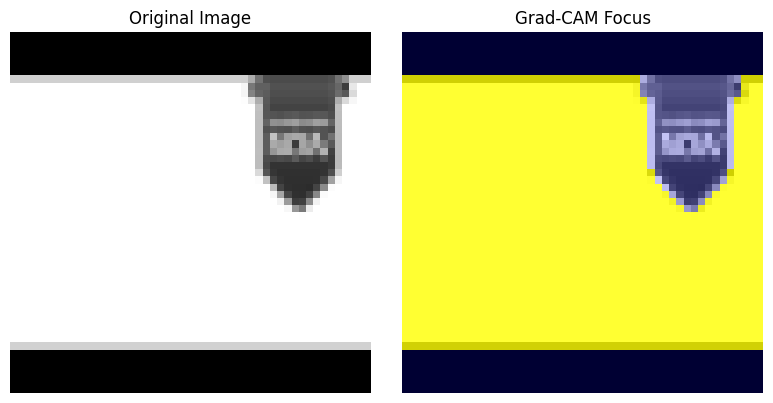

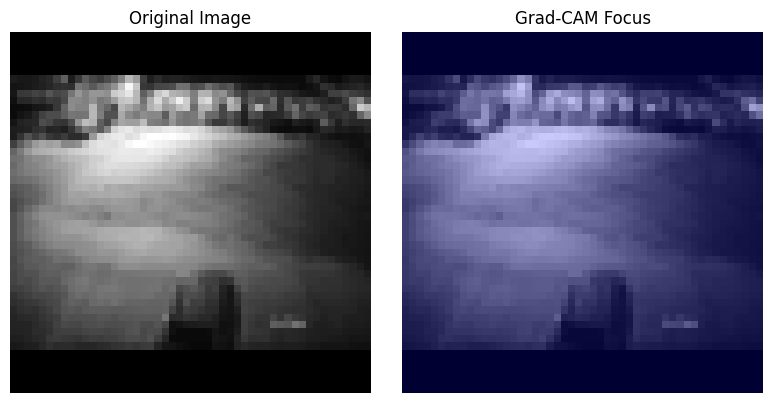

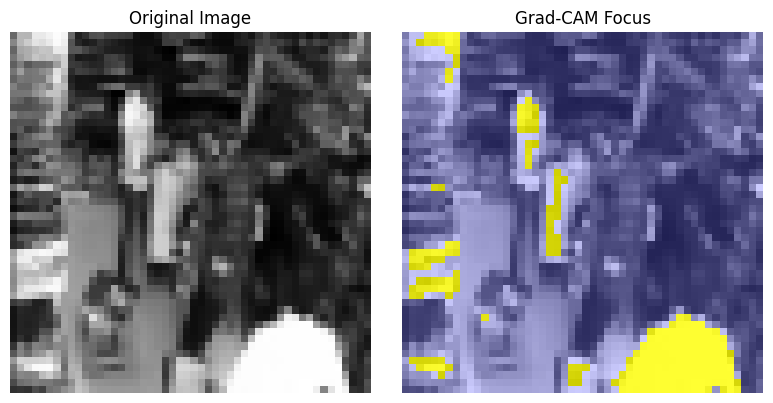

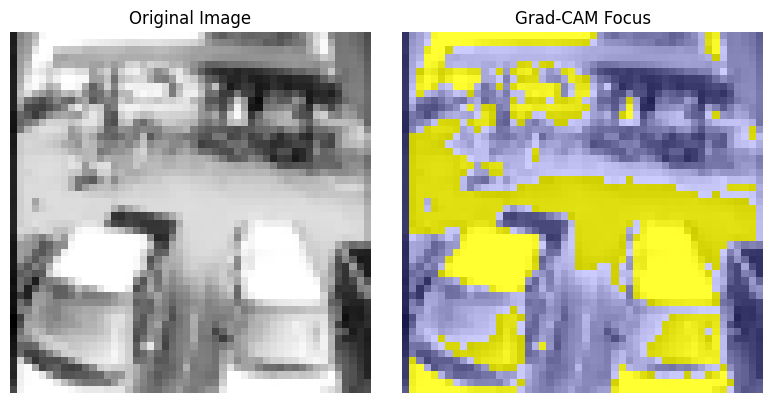

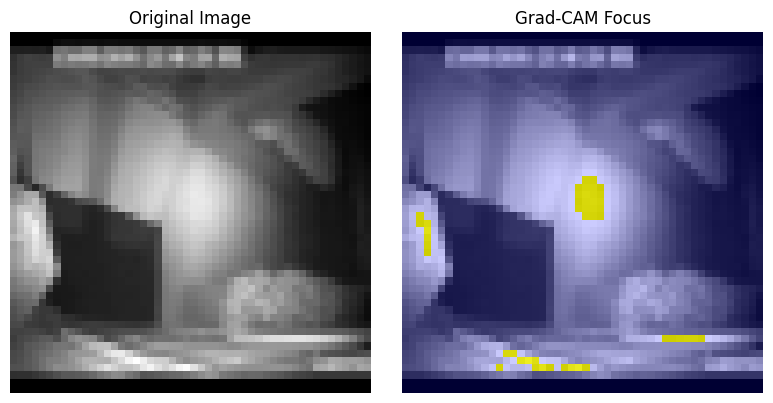

In [ ]:
for i in range(5):
    img = test_images_cnn[i]
    display_gradcam(img, make_gradcam_heatmap([np.expand_dims(img,0), dummy_lstm_input], model_final, "conv2d_11"))


In [ ]:
model_final.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 50, 50, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 50, 50,    │        640 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 50, 50,    │          0 │ conv2d_9[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 25, 25,    │          0 │ leaky_re_lu_12[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 25, 25,    │          0 │ max_pooling2d_9[… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 25, 25,    │     73,856 │ dropout_21[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 25, 25,    │          0 │ conv2d_10[0][0]   │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 2500, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 13, 13,    │          0 │ leaky_re_lu_13[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 2500, 64)  │     16,896 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 13, 13,    │          0 │ max_pooling2d_10… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 2500, 64)  │          0 │ lstm_6[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 13, 13,    │    295,168 │ dropout_22[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 2500, 64)  │     33,024 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 13, 13,    │          0 │ conv2d_11[0][0]   │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 2500, 64)  │          0 │ lstm_7[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 7, 7, 256) │          0 │ leaky_re_lu_14[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,932,329 (41.70 MB)

 Trainable params: 3,644,109 (13.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,288,220 (27.80 MB)

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model_final.evaluate([test_images_cnn, test_images_lstm], test_labels, verbose=0)

# Print the accuracies
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9853
Validation Accuracy: 0.9952
Test Accuracy: 0.9952


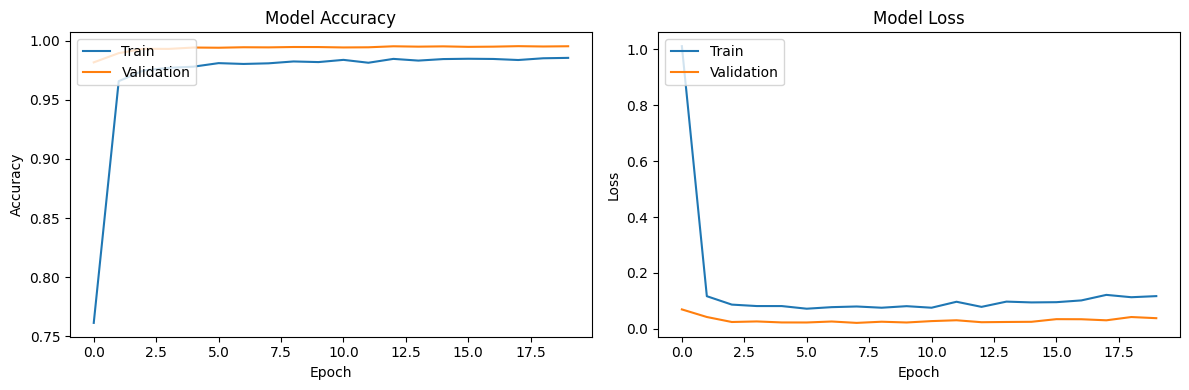

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

923/923 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step
Confusion matrix, without normalization


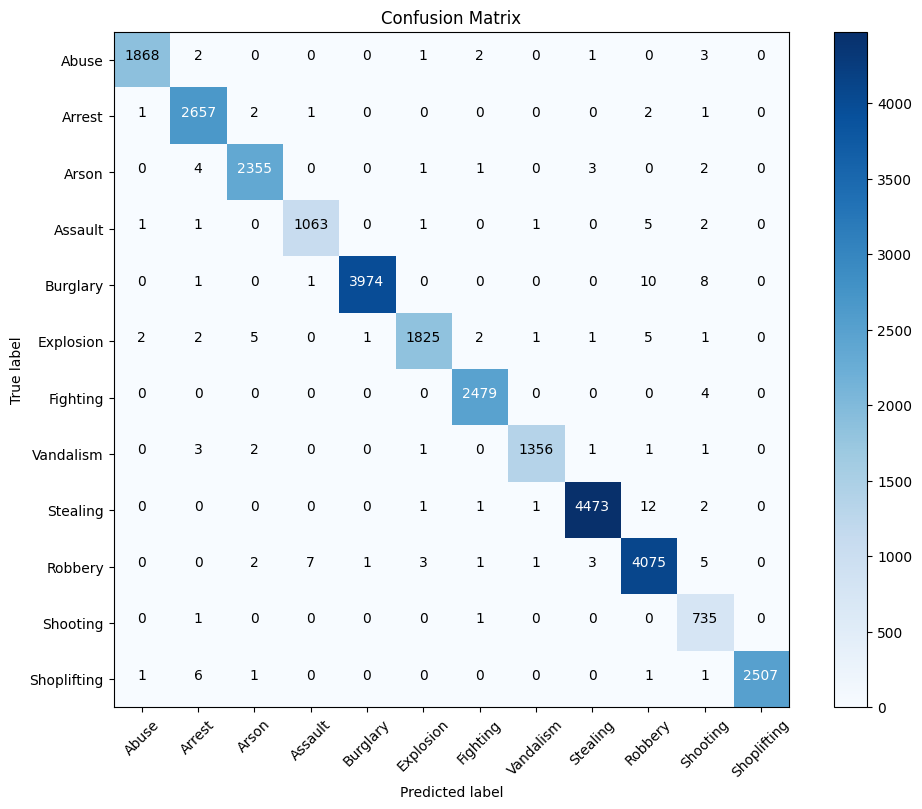


Classification Report:
              precision    recall  f1-score   support

       Abuse       1.00      1.00      1.00      1877
      Arrest       0.99      1.00      0.99      2664
       Arson       0.99      1.00      1.00      2366
     Assault       0.99      0.99      0.99      1074
    Burglary       1.00      0.99      1.00      3994
   Explosion       1.00      0.99      0.99      1845
    Fighting       1.00      1.00      1.00      2483
   Vandalism       1.00      0.99      1.00      1365
    Stealing       1.00      1.00      1.00      4490
     Robbery       0.99      0.99      0.99      4098
    Shooting       0.96      1.00      0.98       737
 Shoplifting       1.00      1.00      1.00      2517

    accuracy                           1.00     29510
   macro avg       0.99      0.99      0.99     29510
weighted avg       1.00      1.00      1.00     29510



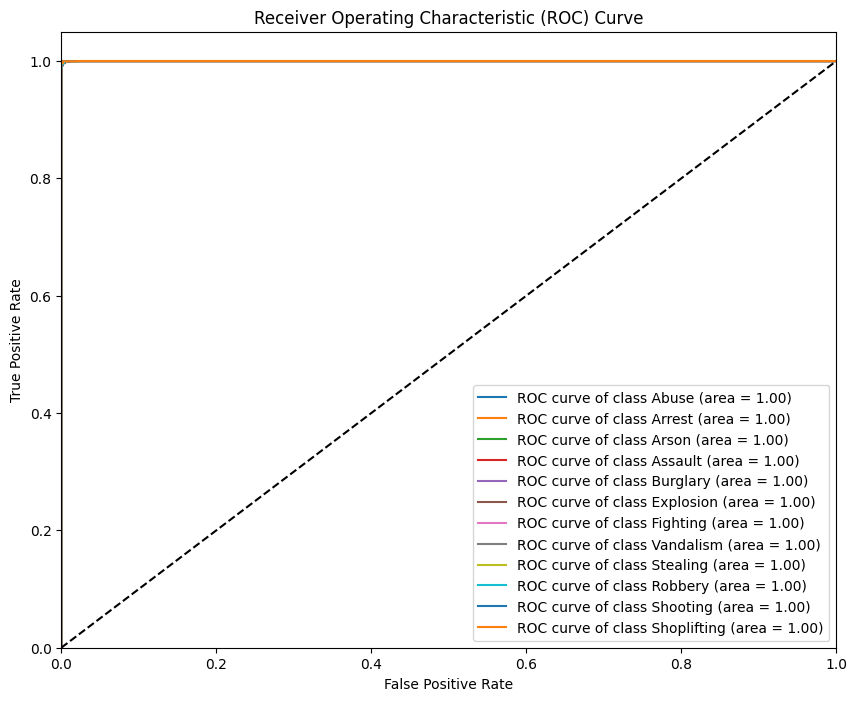

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Get predictions on the test set
y_pred = model_final.predict([test_images_cnn, test_images_lstm])

# Convert predictions and true labels to class indices
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_labels, axis=1)

# ================= Confusion Matrix =================
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]:.2f}" if normalize else f"{cm[i, j]}",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
class_names = list(categories_labels.keys())
plot_confusion_matrix(cnf_matrix, classes=class_names, title='Confusion Matrix')

# ================= Classification Report =================
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ================= ROC Curve =================
# Binarize the output labels
y_true_bin = label_binarize(y_true_classes, classes=np.arange(categories))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(categories):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i in range(categories):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/tmp/ipython-input-2223617211.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


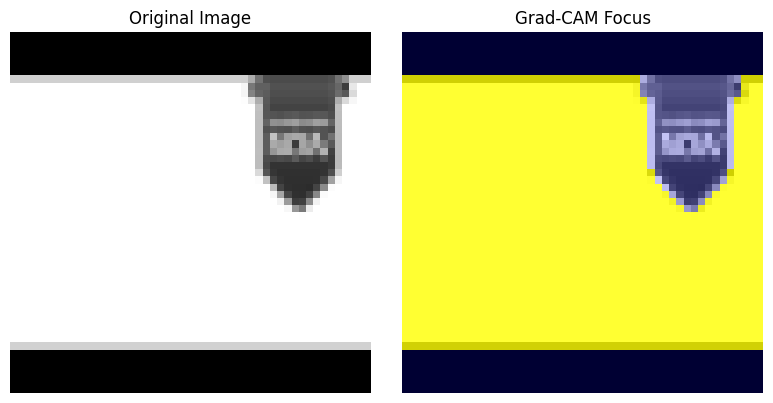

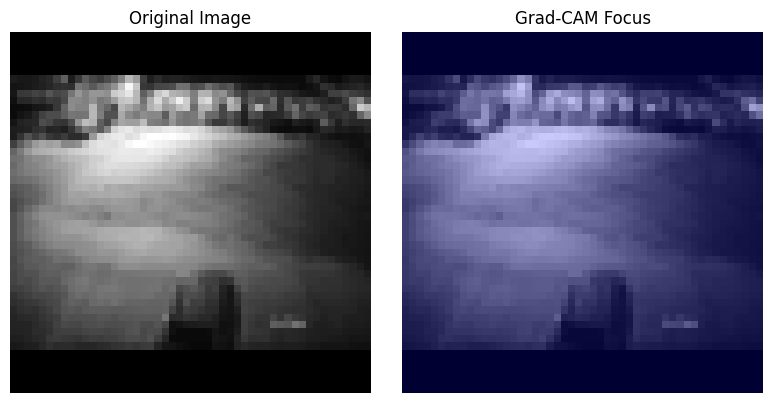

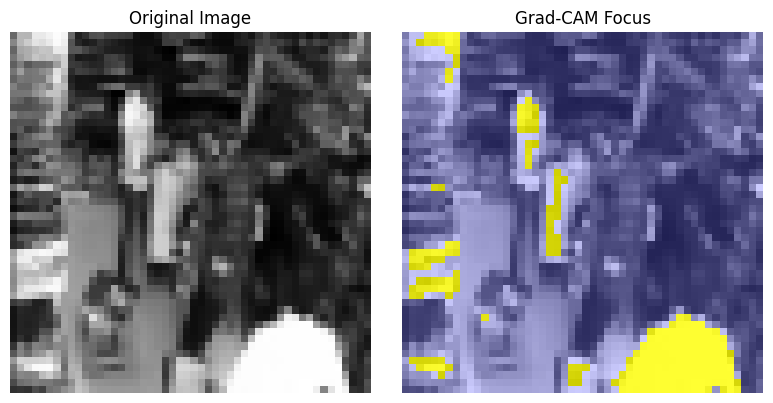

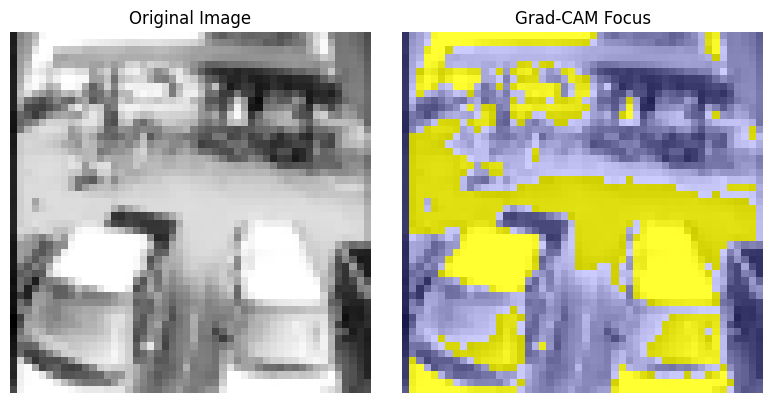

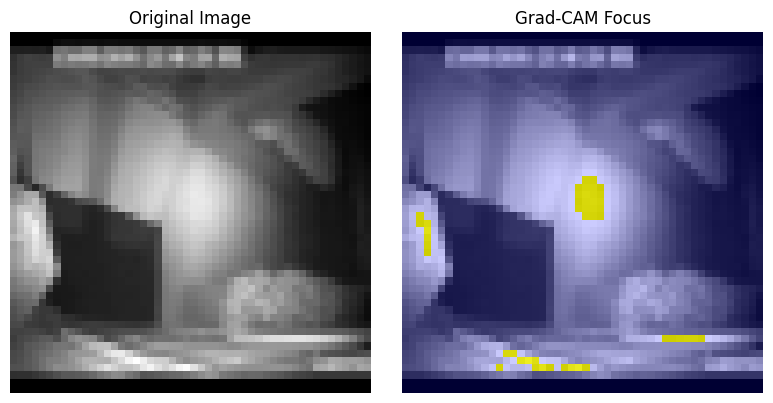

In [ ]:
# ================== PICK SAMPLE IMAGES AND GENERATE HEATMAPS ==================
# You can choose any images from your test or training set
num_samples_to_show = 5

for i in range(num_samples_to_show):
    # Get a sample image and its corresponding LSTM input
    sample_img_cnn = test_images_cnn[i]
    sample_img_lstm = test_images_lstm[i]

    # Expand dimensions for model input
    sample_img_cnn_input = np.expand_dims(sample_img_cnn, axis=0)  # (1, 50, 50, 1)
    sample_img_lstm_input = np.expand_dims(sample_img_lstm, axis=0) # (1, 2500, 1)

    # Generate heatmap using the function defined previously
    # Make sure to use the correct last convolutional layer name from your model summary
    # Based on the summary provided earlier, "conv2d_11" seems to be a good candidate
    heatmap = make_gradcam_heatmap([sample_img_cnn_input, sample_img_lstm_input], model_final, cnn_layer_name="conv2d_11")

    # Display the original image and the Grad-CAM heatmap
    display_gradcam(sample_img_cnn, heatmap)

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import cv2
import tensorflow as tf

def predict_image_from_url(image_url, model, categories_labels):
    """
    Downloads an image from a URL, preprocesses it, and makes a prediction
    using the provided model.

    Args:
        image_url (str): The URL of the image.
        model (tf.keras.Model): The trained model.
        categories_labels (dict): A dictionary mapping category names to labels.

    Returns:
        str: The predicted category name, or None if an error occurred.
    """
    try:
        # Download the image
        response = requests.get(image_url)
        response.raise_for_status()  # Raise an exception for bad status codes

        # Open the image using Pillow
        img = Image.open(BytesIO(response.content))

        # Convert to grayscale and resize
        img_gray = img.convert('L')
        img_resized = img_gray.resize((50, 50))

        # Convert to numpy array
        img_array = np.array(img_resized)

        # Preprocess for model input (CNN and LSTM branches)
        img_cnn_input = img_array.reshape(1, 50, 50, 1)
        img_lstm_input = img_array.reshape(1, -1, 1) # Flatten and add time step dimension

        # Make prediction
        predictions = model.predict([img_cnn_input, img_lstm_input])
        predicted_class_index = np.argmax(predictions, axis=1)[0]

        # Get the category name from the predicted index
        labels_to_categories = {v: k for k, v in categories_labels.items()}
        predicted_category = labels_to_categories.get(predicted_class_index, "Unknown")

        return predicted_category

    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
        return None
    except Exception as e:
        print(f"Error processing image or making prediction: {e}")
        return None

# Example usage:
# Replace with the URL of the image you want to predict
image_url = "YOUR_IMAGE_URL_HERE"
predicted_category = predict_image_from_url(image_url, model_final, categories_labels)

if predicted_category:
    print(f"The predicted category for the image is: {predicted_category}")

Error downloading image: Invalid URL 'YOUR_IMAGE_URL_HERE': No scheme supplied. Perhaps you meant https://YOUR_IMAGE_URL_HERE?
